In [164]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1. Build the sample-point grid
QSP polynomials have definite parity: $P (−x) = ±P (x)$. The target must therefore be defined
symmetrically on $[−1, 1]$. Writing $x = \cos θ$, symmetry in x corresponds to a reflection of θ
about π/2, since $\cos(π − θ) = −\cos θ$.
Proceed as follows. Set $N_\text{half} = 10$ and choose `parity = ’even’`. Construct theta pos, the
Nhalf sample angles in $[0, π/2)$, spaced uniformly in $θ^2$ :

$$\theta_k = \sqrt{\frac{k}{N_\text{half}-1}\cdot \left ( \frac{\pi}2 \right )^ 2}, \quad k=0,1,\dots,N_\text{half}-1$$

Quadratic spacing places more points near $θ = 0$, where high-degree polynomials oscillate most
rapidly — analogous to Gauss–Chebyshev nodes on $[−1, 1]$.
Reflect theta pos to obtain the full grid:

$$\texttt{theta\_full} = [π − θ_{N −1}, \dots , π − θ_0 , θ_0 ,\dots , θ_{N −1}]$$

Reflect the target values to obtain y full, enforcing the chosen parity:

$$\texttt{y\_full} = \begin{cases}[y_{N-1}, \dots, y_0, y_0, \dots, y_{N-1}] && \text{even parity} \\ [-y_{N-1}, \dots, -y_0, y_0, \dots, y_{N-1}] && \text{odd parity}\end{cases}$$

Verify that both theta full and y full have length $2N_\text{half} = 20$.

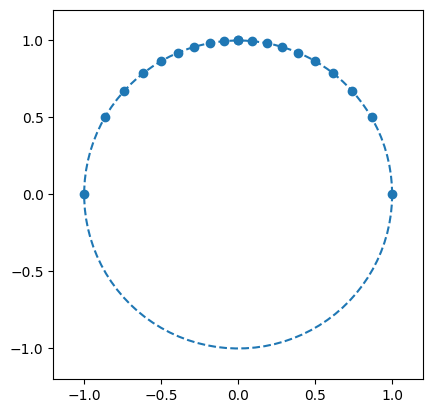

In [165]:
def theta_k(k, N_half):
    return np.sqrt((k/(N_half-1))*np.pow(np.pi / 2, 2))

def get_pts(target_y, parity="even"):
    assert parity == "odd" or parity == "even", f"Parity may only be 'odd' or 'even', got '{parity}'"
    target_y = np.asarray(target_y, dtype=complex)
    N_half = len(target_y)
    theta_half = [theta_k(k, N_half) for k in range(0, N_half)]
    theta_full = np.array([np.pi - theta for theta in theta_half[::-1]] + theta_half)
    
    par_sgn = -1 if parity == "odd" else 1
    y_full = np.concatenate([par_sgn * target_y[::-1], target_y])

    assert len(theta_full) == len(y_full) == 2*N_half, f"Invalid lengths: len(theta_full)={len(theta_full)}, len(y_full)={len(y_full)}, 2*N_half*{2*N_half}"
    return theta_full, y_full, np.cos(theta_full)

ax= plt.gca()
ax.axis("square")
ax.set_ybound(-1.2,1.2)
ax.set_xbound(-1.2,1.2)
angles = np.linspace(0, 2*np.pi, 100)
theta_full, _,_ = get_pts([0]*10)
plt.scatter(np.cos(theta_full), np.sin(theta_full))
plt.plot(np.cos(angles), np.sin(angles), ls="--")
plt.show()

# Step 2. Implement the QSP building blocks
> Goal: Implement the four functions that define QSP: signal operator(x), z rotation(phi), qsp unitary(phases, x), and qsp polynomial(phases, x vals).

All four functions work with 2 × 2 complex matrices. Use your language’s built-in complex
arithmetic throughout.

**Signal operator**. Implement W (x) from Eq. (2). Use the substitution $θ = \arccos(x)$ so that $x = \cos θ$ and $\sqrt{1 − x^2} = \sin θ$; this avoids numerical cancellation near $x = ±1$
**Z-rotation**. Implement $R_z (ϕ)$ from Eq. (3).

**QSP unitary**. Implement Eq. (1): initialize $U = R_z (ϕ_0)$, then for each subsequent phase $ϕ_k$
multiply on the right by $W (x) R_z (ϕ_k )$.

**QSP polynomial**. Return the (0, 0) element of $U_{\vec ϕ} (x)$ evaluated at each value in an array
x vals. This element is the polynomial $P (x)$ of degree d that we want to fit to the target.


Sanity check: for any choice of phases and any $x ∈ [−1, 1]$, $U_{\vec \phi} (x)$ must satisfy $U U^† = I$ to
machine precision. Verify this before proceeding.

In [166]:
def signal_operator(x):
    t = np.arccos(x)
    return np.array([[np.cos(t), (1j)*np.sin(t)], [(1j)*np.sin(t), np.cos(t)]])

def z_rotation(phi):
    arg = 1j * (phi/2)
    return np.array([[np.exp(arg), 0], [0, np.exp(-arg)]])

def qsp_unitary(phases, x):
    assert len(phases) > 1, "need at least 2 phases!"
    U = z_rotation(phases[0])
    for phi in phases[1:]:
        U = U @ signal_operator(x) @ z_rotation(phi)
    return U

def qsp_polynomial(phases, xs):
    return np.array([qsp_unitary(phases, x)[0][0] for x in xs])

NR_TESTS = 100
NR_PHASES = 15
xs = np.random.uniform(-1,1,(NR_TESTS))
phis = np.random.uniform(0,2*np.pi, (NR_TESTS, NR_PHASES))
us = [qsp_unitary(phis[n], xs[n]) for n in range(NR_TESTS)]

max_dev = max(np.max(np.abs(u @ u.conj().T - np.eye(2))) for u in us)
print(f"max deviation: {max_dev:.2e}")

assert all(np.allclose(u @ u.conj().T, np.eye(2)) for u in us)

max deviation: 2.78e-15


# Step 3. Define the objective function
### Goal
Write `objective(phases, x vals, y target)` that returns the scalar loss $\mathscr{L}(\vec ϕ)$
Eq. (4), fitting both the real and imaginary parts of the complex polynomial to the tar-
get. Try different target y values. For instance you could try out a y full where the entries
are either 1 or 0 to begin with. Then you could try a y full where each entry has an
absolute value of 1 but have different phases.


Evaluate the QSP polynomial at all sample points, then compute the sum of squared differences
between $Re[P (x_i)]$ and $Re[f_i ]$, plus the analogous sum for the imaginary parts. This treats the
complex fit as two simultaneous real regression problems.

Fitting the full complex polynomial — rather than only its modulus — has an important conse-
quence: the optimizer has a precise target for both quadratures of P at each point, which typically
provides a stronger gradient signal and avoids the phase-degeneracy plateau that arises when
only $|P|$ is constrained.

**Exploration**. Once you have a working implementation, also try the modulus-only loss
$$\mathscr{L}_\text{abs} (\vec \phi) = \sum_i \left ( |P(x_i)|-|f_i|\right)^2$$
Compare the two formulations: does BFGS converge more reliably with the complex loss or the
modulus loss? Does the final MSE differ? Does the imaginary part of the optimized polynomial
behave differently in the two cases?

In [167]:
def objective(phases, x_vals, y_target):
    assert len(x_vals) == len(y_target)
    p = qsp_polynomial(phases, x_vals)
    res = 0
    for i in range(len(x_vals)):
        res += (p[i].real - y_target[i].real)**2 + (p[i].imag - y_target[i].imag)**2
    return res

def objective_mag(phases, x_vals, y_target):
    assert len(x_vals) == len(y_target)
    p = qsp_polynomial(phases, x_vals)
    res = 0
    for i in range(len(x_vals)):
        res += (np.abs(p[i]) - np.abs(y_target[i]))**2
    return res


# Step 4. Run the optimization
### Goal
⃗Start from a small random perturbation of the zero vector, Use BFGS to minimize $\mathscr{L}(\vec ϕ)$, convert the θ sample points to x values via $x_i = \cos θ_i$ , and always check convergence.

Parameter choices:
- `degree = 20`, giving $d + 1 = 21$ phase parameters.
- Initialize phases to zero, then add a random perturbation of scale ≈ 0.4. This breaks the
symmetry of the all-zero starting point, where the gradient is zero and the optimizer stalls.
- Use gradient tolerance `gtol = 1e-8` and allow up to `maxiter = 10000` iterations.

Always inspect `result.success` and `result.fun` after the run. A large final loss despite a
`success = True` flag can indicate convergence to a local minimum rather than the global one.

**If BFGS fails or stalls.** BFGS is a local, gradient-based method and is sensitive to initial-
ization on this landscape. The loss surface of QSP phase optimization is non-convex and can
contain many shallow local minima, particularly for sharp target functions like the step. If the
final MSE is unsatisfactorily large, consider the following strategies.
- **Reseed**. Re-run with several different random seeds. Because the perturbation is random,
different starting points explore different basins.
- **Increase the degree.** A higher-degree polynomial has more free parameters, which
generally makes it easier for a local optimizer to find a good solution. However, runtime
scales roughly as $O(d · N )$ per function evaluation, so there is a practical limit.
- **Global search with basin-hopping.** The scipy.optimize.basinhopping routine wraps
a local minimizer (BFGS by default) inside a random perturbation loop, allowing it to es-
cape local minima. It is significantly slower but much more reliable for difficult landscapes.
A few hundred basin-hopping steps are usually sufficient.
- **Warm starting.** Optimize first with a low degree (say d = 10), then pad the resulting
phases with small random values and restart at d = 20. The low-degree solution often lies
in a good basin for the higher-degree problem.

In [ ]:
from scipy.optimize import minimize, basinhopping
from dataclasses import dataclass, replace
from typing import Callable, Literal
@dataclass(frozen=True)
class SolveCfg:
    obj: Callable = objective
    disp: bool = True
    init_random_scale: float = 0.4
    parity: Literal["even", "odd"] = "even"
    degree: int = 20

def _do_solve(ys, init_phases, cfg: SolveCfg):
    _, y_full, x_samples = get_pts(ys, cfg.parity)
    result =  minimize(
        cfg.obj,
        init_phases,
        args=(x_samples, y_full),
        method='BFGS',
        options={'maxiter': 10000, 'gtol': 1e-8, 'disp': cfg.disp}
    )
    print(f"Fitting complete with message '{result.message}' result.success={result.success} and result.fun={result.fun}")
    return result.x

def solve(ys, cfg: SolveCfg = SolveCfg()):
    init_phases = np.random.uniform(-cfg.init_random_scale, cfg.init_random_scale, cfg.degree+1)
    return _do_solve(ys, init_phases, cfg)
    
def get_warmstart_solver(warmstart_degree=10, phase_padding_scale=0.15):
    def _do_warmstart(ys, cfg=SolveCfg()):
        starting_phases = solve(ys, replace(cfg, degree=warmstart_degree, disp=False))
        starting_phases = np.concatenate([starting_phases, np.random.uniform(-phase_padding_scale, phase_padding_scale, (cfg.degree - warmstart_degree))])
        print("Warmup complete.")
        assert len(starting_phases) == cfg.degree + 1
        return _do_solve(ys, starting_phases, cfg)
    return _do_warmstart
        

def solve_basinhop(ys, cfg: SolveCfg = SolveCfg()):
    init_phases = np.random.uniform(-cfg.init_random_scale, cfg.init_random_scale, cfg.degree+1)
    _, y_full, x_samples = get_pts(ys, cfg.parity)
    result = basinhopping(cfg.obj, init_phases, minimizer_kwargs={"method": "BFGS", "args": (x_samples, y_full)}, disp=cfg.disp)
    print(f"Fitting complete with message '{result.message}' result.success={result.success} and result.fun={result.fun}")
    return result.x

# Step 5. Evaluate and plot the result

### Goal
Compute the fit errors and produce two plots: the optimized polynomial as a func-
tion of $x = \cos θ$, and as a function of the Fock-state index k defined through $θ = \sqrt{k(\pi/2)^2/(N_\text{half}-1)}$

Evaluate the optimized polynomial on a dense grid and compute the pointwise errors in both
the real and imaginary parts. Report the maximum absolute error and the residual MSE, and
check whether the imaginary part of P is small at the target points (it should be, since the
target imaginary part is zero).

For the first plot, use $x ∈ [−1, 1]$ as the horizontal axis. Show $Re[P (x)]$ and $Im[P (x)]$ alongside
the target values overlaid as scatter points.

For the second plot, convert back to the Fock-state index k: recall that $θ_k = \sqrt{k(\pi/2)^2/(N_\text{half}-1)}$,
so k runs from 0 to $N_\text{half} − 1$ on the positive half and the plot shows how the polynomial behaves
as a function of the mode number. This representation is the physically meaningful one, since
k labels the Fock states that the filter is meant to distinguish.

In [157]:
def create_plt_x(f, sol_phis, y_full, x_samples, title=None):
    ax = f.gca()
    xs = np.linspace(-1, 1, 600)
    poly = qsp_polynomial(sol_phis, xs)
    ax.plot(xs, poly.real, label="Re[P(x)]")
    ax.plot(xs, poly.imag, label="Im[P(x)]")
    ax.scatter(x_samples, y_full.real, label="Re[y_target]")
    ax.scatter(x_samples, y_full.imag, label="Im[y_target]", marker="x")
    if title:
        f.title(title)
    ax.legend()
    return f

def create_plt_k(f, sol_phis, y_full, title=None):
    ax = f.gca()
    N_half = len(y_full) // 2
    ks = np.linspace(0, N_half, 600)
    thetas = np.array([theta_k(k, N_half) for k in ks])
    poly = qsp_polynomial(sol_phis, np.cos(thetas))
    ax.plot(ks, poly.real, label="Re[P(cos(θ_k))]", c="lightgreen", ls="--", marker="D", markevery=60, ms=4, zorder=30)
    ax.plot(ks, poly.imag, label="Im[P(cos(θ_k))]", c="red", ls="--", marker="D", markevery=60, ms=4, zorder=30)
    ax.set_xlabel("k")
    if title:
        f.title(title)
    ax.scatter(np.arange(0, N_half), y_full.real[N_half:], label="Re[y_target]", c="blue", zorder=15)
    ax.scatter(np.arange(0, N_half), y_full.imag[N_half:], label="Im[y_target]", marker="x", c="orange", zorder=15)
    ax.legend()
    return f

def pp_sq_err(y_full, x_samples, phis, print_all=False):
    p_at_samples = qsp_polynomial(phis, x_samples)
    ppe = []
    for i in np.argsort(x_samples):
        err2 = (p_at_samples[i].real - y_full[i].real)**2 + p_at_samples[i].imag**2
        if print_all:
            print(f"  x={x_samples[i]:+.3f}  target={y_full[i].real:.0f}  P_re={p_at_samples[i].real:+.4f}  err²={err2:.4f}")
        ppe.append(err2)
        
    return np.sqrt(np.max(ppe))

def full_eval(ys, d=None, title=None, solver=solve, cfg: SolveCfg = SolveCfg()):
    if d:
        cfg = replace(cfg, degree=d)
    theta_full, y_full, x_full = get_pts(ys, cfg.parity)
    phis = solver(ys, cfg)
    print(f"Max. square pointwise error: {pp_sq_err(y_full, x_full, phis)}")
    create_plt_x(plt, phis, y_full, x_full, title).show()
    create_plt_k(plt, phis, y_full, title).show()
    

         Current function value: 0.000118
         Iterations: 1570
         Function evaluations: 70444
         Gradient evaluations: 1677
Fitting complete with message 'Desired error not necessarily achieved due to precision loss.' result.success=False and result.fun=0.00011766971621636545
Max. square pointwise error: 0.00547239137998658


/home/jay/Source/Bachelor Thesis/.venv/lib/python3.13/site-packages/scipy/optimize/_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


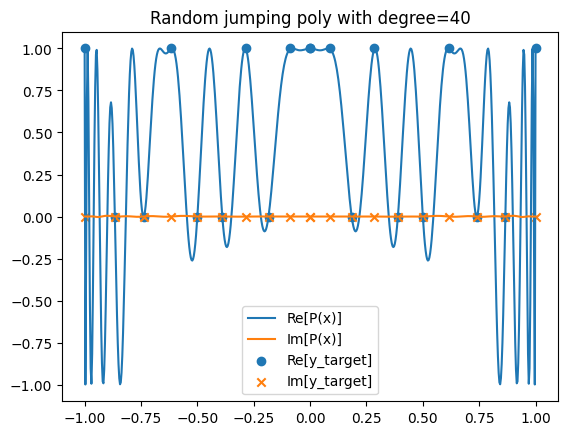

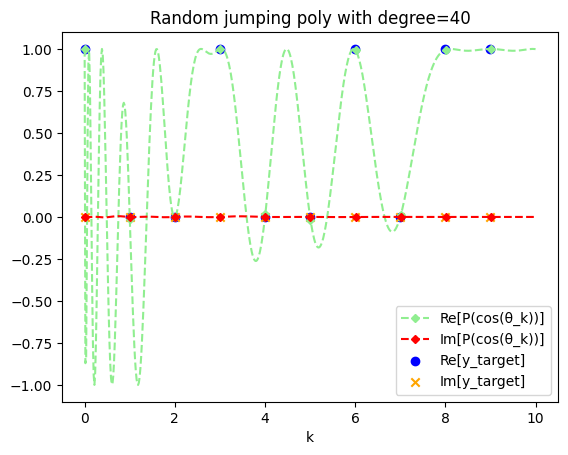

         Current function value: 0.691805
         Iterations: 321
         Function evaluations: 8900
         Gradient evaluations: 404
Fitting complete with message 'Desired error not necessarily achieved due to precision loss.' result.success=False and result.fun=0.6918051078236476
Max. square pointwise error: 0.46165226963712813


/home/jay/Source/Bachelor Thesis/.venv/lib/python3.13/site-packages/scipy/optimize/_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


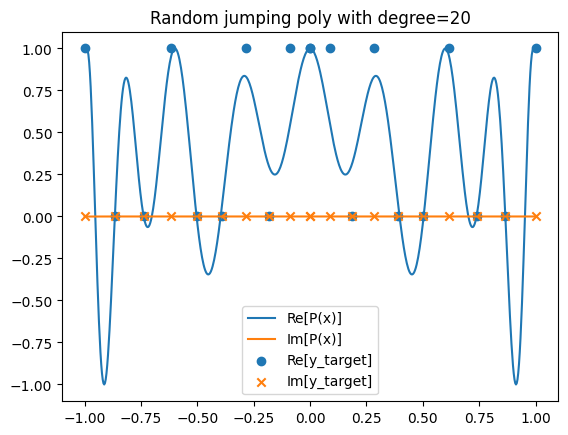

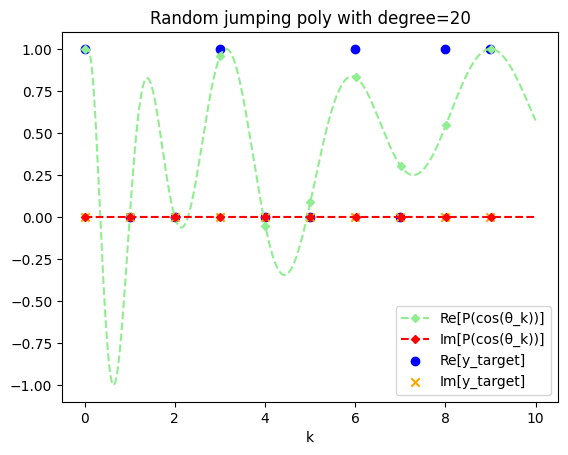

         Current function value: 2.678588
         Iterations: 93
         Function evaluations: 1644
         Gradient evaluations: 136
Fitting complete with message 'Desired error not necessarily achieved due to precision loss.' result.success=False and result.fun=2.6785881387047015
Max. square pointwise error: 0.7237898491673185


/home/jay/Source/Bachelor Thesis/.venv/lib/python3.13/site-packages/scipy/optimize/_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


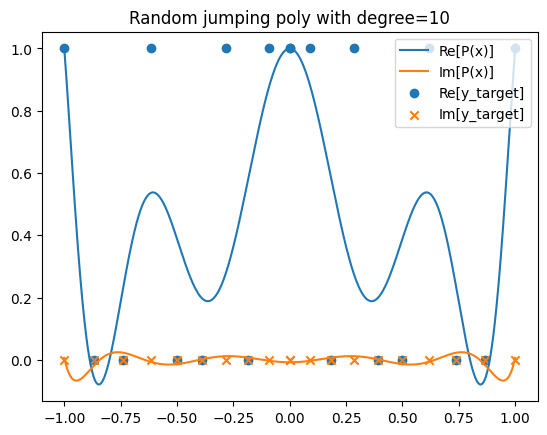

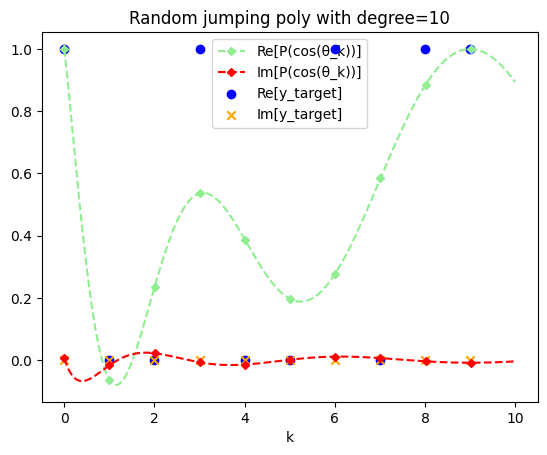

In [158]:
import random
random_ys = [1] + random.choices([0,1], k=8) + [1]
full_eval(random_ys, 40, "Random jumping poly with degree=40")
full_eval(random_ys, 20, "Random jumping poly with degree=20")
full_eval(random_ys, 10, "Random jumping poly with degree=10")

/home/jay/Source/Bachelor Thesis/.venv/lib/python3.13/site-packages/scipy/optimize/_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


         Current function value: 2.678588
         Iterations: 106
         Function evaluations: 1828
         Gradient evaluations: 152
Fitting complete with message 'Desired error not necessarily achieved due to precision loss.' result.success=False and result.fun=2.6785881387046366
Warmup complete.
         Current function value: 0.144380
         Iterations: 576
         Function evaluations: 21132
         Gradient evaluations: 660
Fitting complete with message 'Desired error not necessarily achieved due to precision loss.' result.success=False and result.fun=0.14438027455854502
Max. square pointwise error: 0.21816820422256636


/home/jay/Source/Bachelor Thesis/.venv/lib/python3.13/site-packages/scipy/optimize/_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


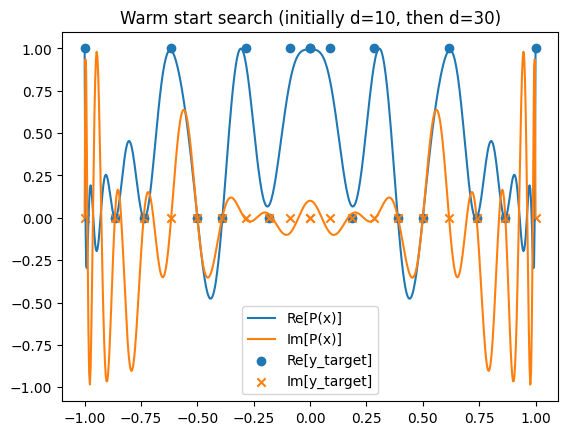

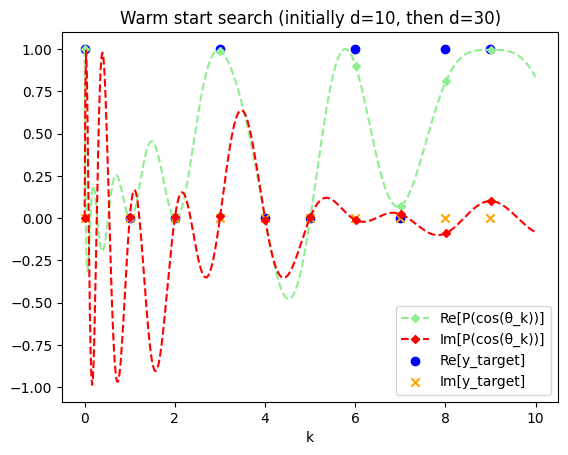

In [159]:
full_eval(random_ys, d=30, title="Warm start search (initially d=10, then d=30)", solver=get_warmstart_solver())

Fitting complete with message '['requested number of basinhopping iterations completed successfully']' result.sucess=True and result.fun=0.1443802746461801
Max. square pointwise error: 0.21816836290121144


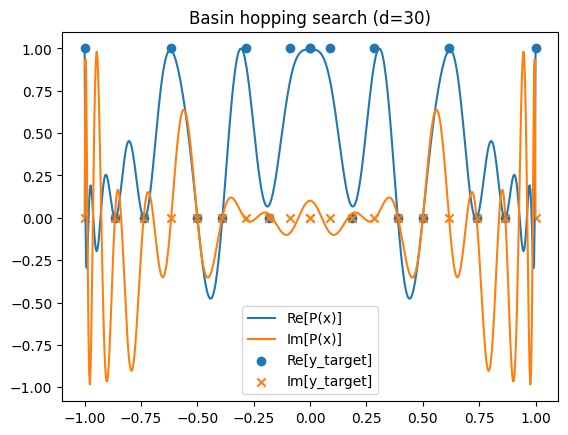

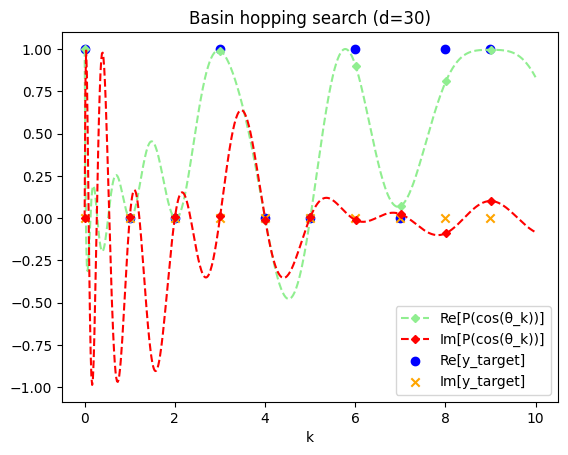

In [160]:
full_eval(random_ys, d=30, title="Basin hopping search (d=30)", solver=solve_basinhop)

         Current function value: 0.023380
         Iterations: 74
         Function evaluations: 2134
         Gradient evaluations: 97
Fitting complete with message 'Desired error not necessarily achieved due to precision loss.' result.success=False and result.fun=0.023379822124174936
Max. square pointwise error: 1.9549411545437867


/home/jay/Source/Bachelor Thesis/.venv/lib/python3.13/site-packages/scipy/optimize/_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


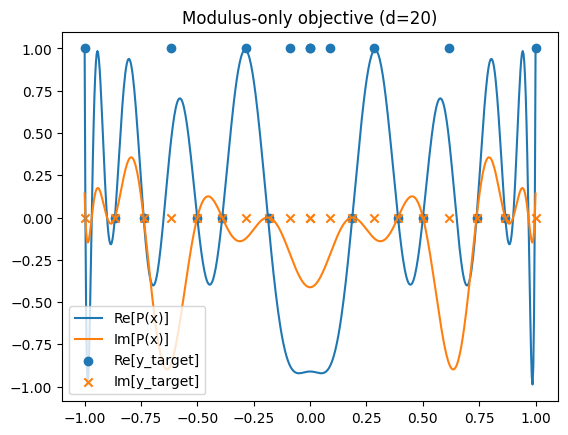

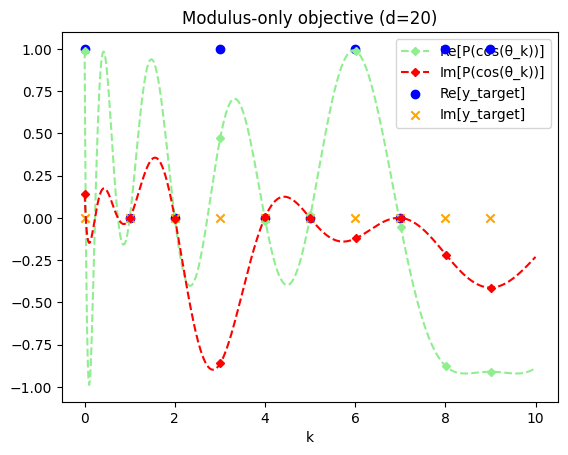

In [161]:
full_eval(random_ys, title="Modulus-only objective (d=20)", cfg=SolveCfg(obj=objective_mag))

/home/jay/Source/Bachelor Thesis/.venv/lib/python3.13/site-packages/scipy/optimize/_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


         Current function value: 12.232236
         Iterations: 44
         Function evaluations: 612
         Gradient evaluations: 51
Fitting complete with message 'Desired error not necessarily achieved due to precision loss.' result.success=False and result.fun=12.232235657866163
Warmup complete.
         Current function value: 0.468364
         Iterations: 125
         Function evaluations: 5164
         Gradient evaluations: 161
Fitting complete with message 'Desired error not necessarily achieved due to precision loss.' result.success=False and result.fun=0.4683640216665123
Max. square pointwise error: 0.9783029461071663


/home/jay/Source/Bachelor Thesis/.venv/lib/python3.13/site-packages/scipy/optimize/_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


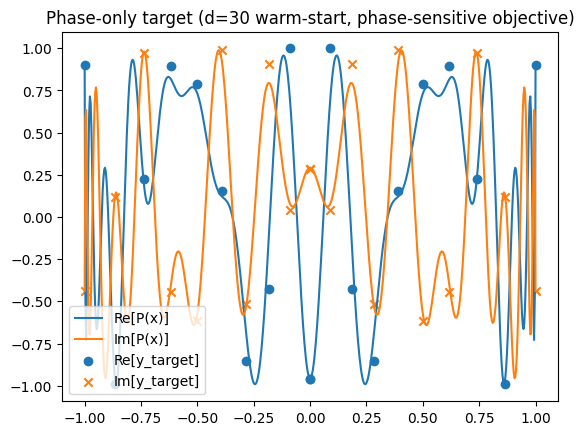

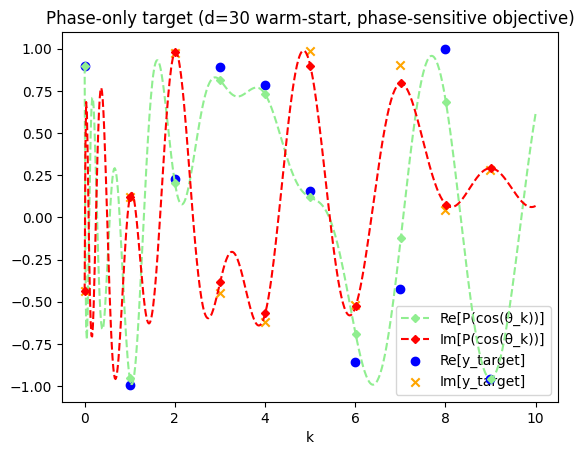

Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 126
         Function evaluations: 1560
         Gradient evaluations: 130
Fitting complete with message 'Optimization terminated successfully.' result.success=True and result.fun=1.0311100018602214e-10
Warmup complete.
Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 401
         Function evaluations: 13248
         Gradient evaluations: 414
Fitting complete with message 'Optimization terminated successfully.' result.success=True and result.fun=9.101509591635787e-11
Max. square pointwise error: 1.8215311052845617


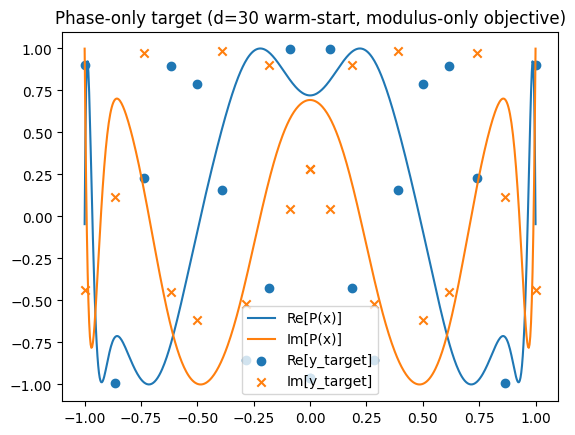

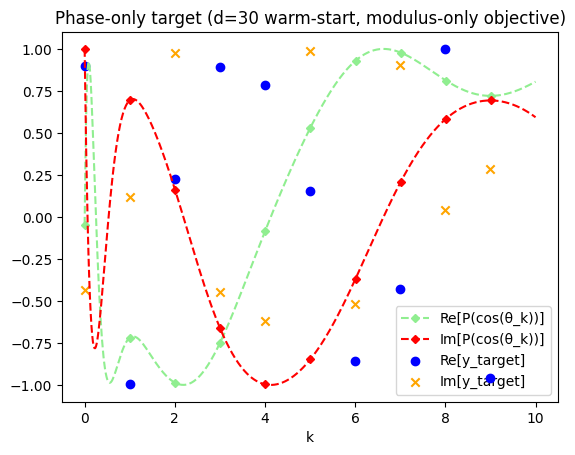

In [162]:
phased_ys = [np.exp(1j * p) for p in np.random.uniform(0, 2*np.pi, 10)]
full_eval(phased_ys, 30, title="Phase-only target (d=30 warm-start, phase-sensitive objective)", solver=get_warmstart_solver())
full_eval(phased_ys, 30, title="Phase-only target (d=30 warm-start, modulus-only objective)", solver=get_warmstart_solver(), cfg=SolveCfg(obj=objective_mag))

(array([ 6.12323400e-17, -8.97145618e-02, -1.84422430e-01, -2.84271502e-01,
       -3.89412698e-01, -5.00000000e-01, -6.16190508e-01, -7.38144485e-01,
       -8.66025404e-01, -1.00000000e+00,  1.00000000e+00,  8.66025404e-01,
        7.38144485e-01,  6.16190508e-01,  5.00000000e-01,  3.89412698e-01,
        2.84271502e-01,  1.84422430e-01,  8.97145618e-02,  6.12323400e-17]), array([-0.+0.j, -1.+0.j, -1.+0.j, -1.+0.j, -1.+0.j, -1.+0.j, -0.+0.j,
       -1.+0.j, -1.+0.j, -1.+0.j,  1.+0.j,  1.+0.j,  1.+0.j,  0.+0.j,
        1.+0.j,  1.+0.j,  1.+0.j,  1.+0.j,  1.+0.j,  0.+0.j]))
Fitting complete with message 'Desired error not necessarily achieved due to precision loss.' result.success=False and result.fun=0.8798468821292176
Warmup complete.
(array([ 6.12323400e-17, -8.97145618e-02, -1.84422430e-01, -2.84271502e-01,
       -3.89412698e-01, -5.00000000e-01, -6.16190508e-01, -7.38144485e-01,
       -8.66025404e-01, -1.00000000e+00,  1.00000000e+00,  8.66025404e-01,
        7.38144485e-01,  6.

/home/jay/Source/Bachelor Thesis/.venv/lib/python3.13/site-packages/scipy/optimize/_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


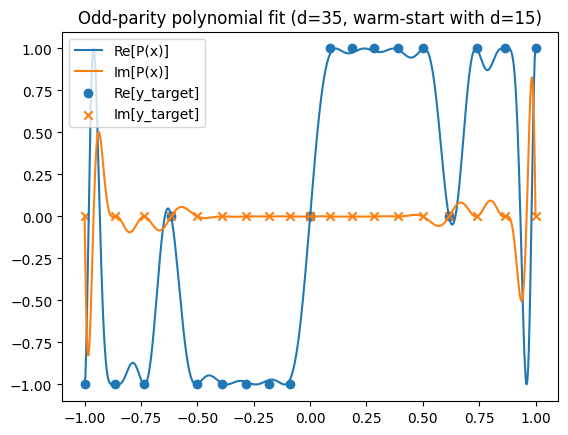

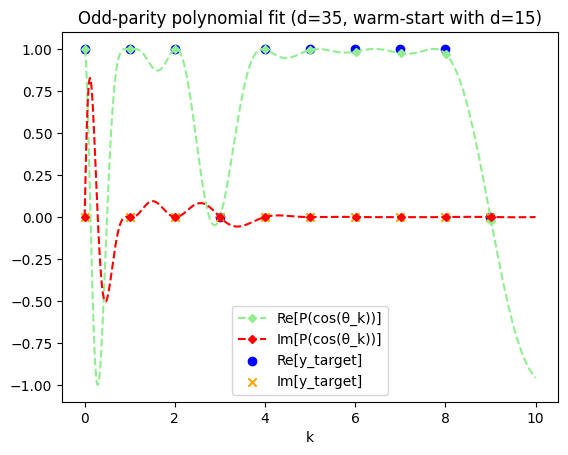

In [172]:
random_ys = [1] + random.choices([0,1], k=8) + [0]
full_eval(random_ys, 35, title="Odd-parity polynomial fit (d=35, warm-start with d=15)", solver=get_warmstart_solver(15), cfg=SolveCfg(parity="odd"))

### Notes:
- mathematical constraint: $|P(\pm 1)|=1$ -> this will stop the error from going below 2 for targets that have y=0 for those extrema.
- i don't understand why the quadratic spacing of $\theta$ means higher density at $\theta=0$, to me it seems the opposite is true, the density is lowest for $\theta=0$